In [23]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
import itertools

##  Get LSTM Model Predictions

In [27]:

df = pd.read_csv('daily_health.csv')
feature_cols = ['StepTotal', 'total_sleep_min', 'hourly_heart_rate', 'Calories']
label_cols = ['lack_of_exercise', 'poor_sleep', 'high_heart_rate', 'high_calorie']


model = load_model('best_deep_lstm_model.h5')



In [28]:
X = df[feature_cols].values
X = X.reshape((X.shape[0], 1, X.shape[1]))

# Get predicted labels
# y_pred = (model.predict(X) > 0.5).astype(int)  
y_prob = model.predict(X, verbose=0)
y_pred = (y_prob >= 0.5).astype(int)
df[label_cols] = y_pred 


## Build Prediction Table

The LSTM produces four binary unhealthy-habit predictions for each complete 24-hour sequence.  
These predictions become the state representation used by the reinforcement-learning agent.


In [29]:


prediction_df = df.copy()


probability_cols = [
    f"{label}_probability"
    for label in label_cols
]

prediction_df[probability_cols] = y_prob


prediction_df[label_cols] = y_pred

print("Prediction table shape:", prediction_df.shape)
display(prediction_df.head())


Prediction table shape: (8499, 15)


,Id,datetime,StepTotal,total_sleep_min,hourly_heart_rate,Calories,date,lack_of_exercise,poor_sleep,high_heart_rate,high_calorie,lack_of_exercise_probability,poor_sleep_probability,high_heart_rate_probability,high_calorie_probability
0,2022484408,2016-04-01 07:00:00,123.0,0.0,100.326531,78.0,2016-04-01,0,0,0,0,0.405411,0.304946,0.315613,0.355691
1,2022484408,2016-04-01 08:00:00,440.0,0.0,71.396419,115.0,2016-04-01,0,0,0,0,0.350475,0.412125,0.354191,0.457324
2,2022484408,2016-04-01 09:00:00,4994.0,0.0,121.205323,427.0,2016-04-01,0,0,0,0,0.375109,0.419438,0.345384,0.424039
3,2022484408,2016-04-01 10:00:00,2926.0,0.0,97.129771,248.0,2016-04-01,0,0,0,0,0.375392,0.419165,0.345359,0.423605
4,2022484408,2016-04-01 11:00:00,0.0,0.0,90.000000,62.0,2016-04-01,0,0,0,0,0.446629,0.319224,0.312358,0.377275



## Define the Reinforcement-Learning Environment

There are 16 possible states because each of the four predicted habits can be either 0 or 1.

The action space contains five recommendations:

1. Increase physical activity
2. Improve sleep routine
3. Practise relaxation
4. Reduce calorie intake
5. Maintain the current healthy routine

The fifth action is necessary for the healthy state `[0, 0, 0, 0]`.


In [30]:

import random

state_space = list(itertools.product([0, 1], repeat=4))

state_to_idx = {
    state: idx
    for idx, state in enumerate(state_space)
}

action_space = [
    "Increase walking and physical activity",
    "Improve sleep routine and go to bed earlier",
    "Practise relaxation or breathing exercises",
    "Reduce calorie intake and choose a lighter meal",
    "Maintain the current healthy routine"
]

num_actions = len(action_space)

q_table = np.zeros(
    (len(state_space), num_actions),
    dtype=np.float32
)

print("Number of states:", len(state_space))
print("Number of actions:", num_actions)


Number of states: 16
Number of actions: 5



## Define Action-Dependent Reward and Simulated Transition

The Fitbit dataset does not contain real user responses after recommendations.  
Therefore, a simulated feedback environment is used.

A positive reward is assigned when:

- action 0 matches lack of exercise;
- action 1 matches poor sleep;
- action 2 matches high heart rate;
- action 3 matches high calorie intake;
- action 4 is selected for a fully healthy state.

When a recommendation matches an active unhealthy habit, the corresponding label is simulated as improving from `1` to `0`.


In [31]:

def validate_state(state):
    state_array = np.asarray(state, dtype=int)

    if state_array.shape != (4,):
        raise ValueError(
            "State must contain exactly four binary values."
        )

    if not np.isin(state_array, [0, 1]).all():
        raise ValueError(
            "State values must contain only 0 and 1."
        )

    return state_array


def calculate_reward(state, action_idx):
    state_array = validate_state(state)

    if not 0 <= action_idx < num_actions:
        raise ValueError("Invalid action index.")

    # Maintain routine is correct only for a fully healthy state.
    if action_idx == 4:
        return 1 if state_array.sum() == 0 else -1

    # Actions 0-3 map directly to labels 0-3.
    return 1 if state_array[action_idx] == 1 else -1


def simulate_transition(state, action_idx):
    current_state = validate_state(state)
    reward = calculate_reward(current_state, action_idx)

    next_state = current_state.copy()

    if reward == 1 and action_idx < 4:
        next_state[action_idx] = 0

    return tuple(next_state.tolist()), reward


def choose_best_action(q_values):
    q_values = np.asarray(q_values)

    best_value = np.max(q_values)
    candidate_actions = np.flatnonzero(
        q_values == best_value
    )

    return int(np.random.choice(candidate_actions))


## Train the Q-Learning Agent

In [32]:

alpha = 0.1
gamma = 0.9

epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995

num_episodes = 5000

predicted_states = [
    tuple(row)
    for row in prediction_df[label_cols]
        .astype(int)
        .to_numpy()
]

training_states = predicted_states + state_space

episode_rewards = []
epsilon_history = []

for episode in range(num_episodes):
    state = random.choice(training_states)
    state_idx = state_to_idx[state]

  
    if np.random.random() < epsilon:
        action_idx = np.random.randint(num_actions)
    else:
        action_idx = choose_best_action(
            q_table[state_idx]
        )

    next_state, reward = simulate_transition(
        state,
        action_idx
    )

    next_state_idx = state_to_idx[next_state]

    target = (
        reward
        + gamma * np.max(q_table[next_state_idx])
    )

    q_table[state_idx, action_idx] += alpha * (
        target
        - q_table[state_idx, action_idx]
    )

    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )

    episode_rewards.append(reward)
    epsilon_history.append(epsilon)

print("Training complete")
print("Final epsilon:", round(epsilon, 4))


Training complete
Final epsilon: 0.05


## Inspect the Learned Recommendation Policy

In [33]:

def recommend_action(state):
    validated_state = tuple(
        validate_state(state).tolist()
    )

    state_idx = state_to_idx[validated_state]
    action_idx = choose_best_action(
        q_table[state_idx]
    )

    return {
        "state": validated_state,
        "action_index": action_idx,
        "recommendation": action_space[action_idx],
        "simulated_reward": calculate_reward(
            validated_state,
            action_idx
        )
    }


policy_rows = []

for state in state_space:
    result = recommend_action(state)

    policy_rows.append({
        "state": "".join(map(str, state)),
        **dict(zip(label_cols, state)),
        "selected_action": result["action_index"],
        "recommendation": result["recommendation"],
        "simulated_reward": result["simulated_reward"]
    })

policy_df = pd.DataFrame(policy_rows)
display(policy_df)


,state,lack_of_exercise,poor_sleep,high_heart_rate,high_calorie,selected_action,recommendation,simulated_reward
0,0000,0,0,0,0,4,Maintain the current healthy routine,1
1,0001,0,0,0,1,3,Reduce calorie intake and choose a lighter meal,1
2,0010,0,0,1,0,3,Reduce calorie intake and choose a lighter meal,-1
3,0011,0,0,1,1,1,Improve sleep routine and go to bed earlier,-1
4,0100,0,1,0,0,2,Practise relaxation or breathing exercises,-1
5,0101,0,1,0,1,2,Practise relaxation or breathing exercises,-1
6,0110,0,1,1,0,4,Maintain the current healthy routine,-1
7,0111,0,1,1,1,2,Practise relaxation or breathing exercises,1
8,1000,1,0,0,0,0,Increase walking and physical activity,1
9,1001,1,0,0,1,2,Practise relaxation or breathing exercises,-1


## Evaluate the Simulated Policy

In [34]:

policy_success = (
    policy_df["simulated_reward"] == 1
).mean()

print(
    "Simulated policy success rate:",
    f"{policy_success:.2%}"
)

print(
    "This measures agreement with the simulated "
    "reward rules, not real-world health improvement."
)


Simulated policy success rate: 56.25%
This measures agreement with the simulated reward rules, not real-world health improvement.


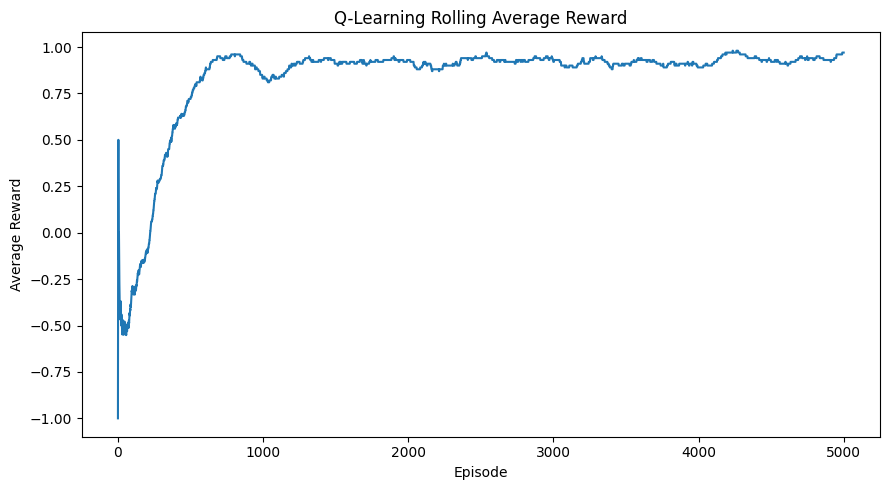

In [35]:

import matplotlib.pyplot as plt

rolling_reward = (
    pd.Series(episode_rewards)
      .rolling(window=200, min_periods=1)
      .mean()
)

plt.figure(figsize=(9, 5))
plt.plot(rolling_reward)
plt.title("Q-Learning Rolling Average Reward")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.tight_layout()
plt.show()


## Generate Recommendations for LSTM-Predicted States

In [36]:

recommendation_rows = []

for _, row in prediction_df.iterrows():
    state = tuple(
        int(row[label])
        for label in label_cols
    )

    result = recommend_action(state)

    recommendation_rows.append({
        **row.to_dict(),
        "selected_action": result["action_index"],
        "recommendation": result["recommendation"],
        "simulated_reward": result["simulated_reward"]
    })

recommendation_df = pd.DataFrame(
    recommendation_rows
)

display(
    recommendation_df[
        [
            "Id",
            "date",
            *label_cols,
            "recommendation",
            "simulated_reward"
        ]
    ].head(10)
)


,Id,date,lack_of_exercise,poor_sleep,high_heart_rate,high_calorie,recommendation,simulated_reward
0,2022484408,2016-04-01,0,0,0,0,Maintain the current healthy routine,1
1,2022484408,2016-04-01,0,0,0,0,Maintain the current healthy routine,1
2,2022484408,2016-04-01,0,0,0,0,Maintain the current healthy routine,1
3,2022484408,2016-04-01,0,0,0,0,Maintain the current healthy routine,1
4,2022484408,2016-04-01,0,0,0,0,Maintain the current healthy routine,1
5,2022484408,2016-04-01,0,0,0,0,Maintain the current healthy routine,1
6,2022484408,2016-04-01,0,0,0,0,Maintain the current healthy routine,1
7,2022484408,2016-04-01,0,0,0,0,Maintain the current healthy routine,1
8,2022484408,2016-04-01,0,0,0,0,Maintain the current healthy routine,1
9,2022484408,2016-04-01,0,0,0,0,Maintain the current healthy routine,1


In [37]:
correct_actions = 0

for state in state_space:
    state_idx = state_to_idx[state]
    action_idx = choose_best_action(
        q_table[state_idx]
    )

    reward = calculate_reward(
        state,
        action_idx
    )

    if reward == 1:
        correct_actions += 1

recommendation_accuracy = (
    correct_actions / len(state_space)
)

print(
    f"Recommendation accuracy: "
    f"{recommendation_accuracy * 100:.2f}%"
)

Recommendation accuracy: 68.75%


## Test a Custom Health State

In [38]:

custom_state = [1, 0, 1, 0]

custom_result = recommend_action(custom_state)

print("State:", custom_result["state"])
print(
    "Recommendation:",
    custom_result["recommendation"]
)
print(
    "Simulated reward:",
    custom_result["simulated_reward"]
)


State: (1, 0, 1, 0)
Recommendation: Practise relaxation or breathing exercises
Simulated reward: 1
